# DEAP

Use SSNAP coeff variations as input

In [1]:
import deap

In [2]:
import random

from deap import base
from deap import creator
from deap import tools

In [3]:
import numpy as np
import os
import polars as pl
import matplotlib.pyplot as plt

In [4]:
from itertools import product

## Load admissions data

In [5]:
path_to_msoa_stats = os.path.join('..', 'data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [6]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662


Check sum of admissions for Welsh areas:

In [7]:
df_stats.filter(df_stats['country'] == 'W')['admissions'].sum()

0.0

Welsh data is always zero so remove it.

In [8]:
df_stats = df_stats.filter(df_stats['country'] != 'W')

Recalculate total numbers of patients:

In [9]:
df_stats = df_stats.with_columns((pl.col('good_health') + pl.col('fair health') + pl.col('bad health')).alias('total_health'))

In [10]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526


Pick out column names for the health and age proportions:

In [11]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]

Calculate numbers of patients in each age band:

In [12]:
age_numbers = []

for col in props_age:
    new_col = col.replace('_proportion', '')
    age_numbers.append(new_col)
    df_stats = df_stats.with_columns((pl.col(col) * pl.col('total_health')).alias(new_col))

In [13]:
df_stats[['total_health'] + props_age + age_numbers].head()

total_health,age_less65_proportion,age_65_proportion,age_70_proportion,age_75_proportion,age_over80_proportion,age_less65,age_65,age_70,age_75,age_over80
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8524,0.7872,0.0559,0.0528,0.0422,0.062,6710.0928,476.4916,450.0672,359.7128,528.488
6634,0.7467,0.0578,0.0774,0.0492,0.0692,4953.6078,383.4452,513.4716,326.3928,459.0728
7100,0.7729,0.0609,0.0582,0.0421,0.0661,5487.59,432.39,413.22,298.91,469.31
10127,0.8091,0.0465,0.0438,0.0367,0.0638,8193.7557,470.9055,443.5626,371.6609,646.1026
8526,0.7643,0.0597,0.067,0.0425,0.0662,6516.4218,509.0022,571.242,362.355,564.4212


## Set up bins for IMD scores

Use quantiles so that each bin contains 10% of the MSOA (to match plot notebook).

The resulting dictionary has keys for which quantile it is and values for the left side (smaller, minimum value in bin) of the IMD bin.

In [14]:
dict_quantiles = {}

for q in np.arange(0.0, 1.01, 0.2):
    v = df_stats['IMD2019Score'].quantile(q)
    # Flip the ranking because lower rank (more deprived) should be for
    # higher IMD scores (more deprived).
    q_store = 1.0 - q
    dict_quantiles[round(q_store, 1)] = round(v, 5)

In [15]:
dict_quantiles

{1.0: 2.2122,
 0.8: 10.369,
 0.6: 15.2564,
 0.4: 21.81475,
 0.2: 31.84075,
 0.0: 87.02675}

In [16]:
qmin_list = sorted(dict_quantiles.keys())[:-1]

In [17]:
qmin_list

[0.0, 0.2, 0.4, 0.6, 0.8]

Pick out just the values for the left edges of the bins:

In [18]:
imd_bin_left_edges = {}
for k in list(dict_quantiles.keys())[:-1]:
    imd_bin_left_edges[k] = dict_quantiles[k]

In [19]:
imd_bin_left_edges

{1.0: 2.2122, 0.8: 10.369, 0.6: 15.2564, 0.4: 21.81475, 0.2: 31.84075}

Place MSOA into these bins:

In [20]:
# Make columns for the results with a placeholder value:
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_min'))
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_max'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_min'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_max'))

for q, quantile in enumerate(list(dict_quantiles.keys())[:-1]):
    # Pick out the bin edges:
    qmin = list(dict_quantiles.keys())[q+1]
    q0 = dict_quantiles[quantile]
    q1 = dict_quantiles[qmin]
    # Find a mask for the demographic data that contains
    # only MSOA with IMD scores in this bin.
    mask = (df_stats['IMD2019Score'] >= q0) & (df_stats['IMD2019Score'] < q1)
    if q == len(dict_quantiles) - 2:
        # Also allow values at the right edge of the final bin.
        mask = mask | (df_stats['IMD2019Score'] == q1)

    # Update the bin min/max values for these rows:
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(qmin)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_min'))  # otherwise keep the existing value
        .name.keep()
    )
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(quantile)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_max'))  # otherwise keep the existing value
        .name.keep()
    )

Check that data was binned correctly:

In [21]:
df_stats[['IMD2019Score', 'depriv_quantile_min', 'depriv_quantile_max']]

IMD2019Score,depriv_quantile_min,depriv_quantile_max
f64,f64,f64
16.924833,0.4,0.6
6.4704,0.8,1.0
13.7334,0.6,0.8
26.199857,0.2,0.4
11.7948,0.6,0.8
…,…,…
3.25925,0.8,1.0
7.29475,0.8,1.0
12.117,0.6,0.8


## Admissions prediction setup

In [22]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    # yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    yhat = sum(
        [x_lists[i] * coeffs[i] for i in range(len(coeffs))]
    )
    return yhat.to_numpy().tolist()

Goodness check option 1: This calculates the sum of the square of the differences between predicted and actual admission numbers:

In [23]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (np.array(yhat) - np.array(y))**2.0
    # Sum of differences:
    sum_sqres = sqres.sum()
    return np.sqrt(sum_sqres)

Goodness check option 2: This calculates the mean absolute difference between the predicted and real admissions numbers:

In [24]:
def find_mean_abs_diff(yhat, y):
    # Difference from actual:
    absres = np.abs((yhat - y))
    # Mean of differences:
    mean_absres = absres.mean()
    return mean_absres

To check accuracy, the following function calculates R-squared:

In [25]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y = np.array(y)
    yhat = np.array(yhat)
    y_mean = np.mean(y)#.mean()
    ss_res = np.sum(((yhat - y)**2.0))#.sum()
    ss_tot = np.sum(((y - y_mean)**2.0))#.sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

## Parameter setup

Which values are allowed for each coefficient?


Set up options for how much the SSNAP coefficients can be scaled by:

In [26]:
scale_options = np.round(np.arange(0.6, 1.41, 0.1), 1)

scale_options

array([0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4])

In [27]:
scale_option_combos = np.array([s for s in product(scale_options, repeat=5)])

# Only keep combos where scales decrease/stay same with depriv quantile
# (i.e. scale is larger when deprivation higher):
mask = (np.diff(scale_option_combos, axis=1) <= 0.0).all(axis=1)
scale_option_combos = scale_option_combos[mask]

# # Only keep combos where the five sets of scales sum to five.
# # Then the total England admissions should be bang-on,
# # and it's just a case of checking how good the fit is for each MSOA.    # - no, wrong
# mask = (np.sum(scale_option_combos, axis=1) == 5.0)
# scale_option_combos = scale_option_combos[mask]

In [28]:
len(scale_option_combos)

1287

In [29]:
scale_option_combos[:5]

array([[0.6, 0.6, 0.6, 0.6, 0.6],
       [0.7, 0.6, 0.6, 0.6, 0.6],
       [0.7, 0.7, 0.6, 0.6, 0.6],
       [0.7, 0.7, 0.7, 0.6, 0.6],
       [0.7, 0.7, 0.7, 0.7, 0.6]])

In [30]:
scale_option_combos[-5:]

array([[1.4, 1.4, 1.4, 1.4, 1. ],
       [1.4, 1.4, 1.4, 1.4, 1.1],
       [1.4, 1.4, 1.4, 1.4, 1.2],
       [1.4, 1.4, 1.4, 1.4, 1.3],
       [1.4, 1.4, 1.4, 1.4, 1.4]])

Set up SSNAP coefficients:

In [31]:
# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}' for q in qmin_list for a in age_numbers]

coeff_names

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

In [32]:
# from previous notebook
coeffs_ssnap = [0.000408, 0.002644, 0.003735, 0.006005, 0.011558]

Set up all combos of starting coefficients:

In [33]:
# Store start combos of coeffs in here:
coeffs_init_start = {}

for s, scale_options_here in enumerate(scale_option_combos):
    # coeffs_init = list(np.round(np.concatenate([np.array(coeffs_ssnap) * s for s in scale_options_here]), 8))
    coeffs_init = list(np.round(np.concatenate([np.ones(5) * s for s in scale_options_here]), 8))
    coeffs_init_start[s] = coeffs_init

# coeffs_init_grid = np.array(coeffs_init).reshape(5, 5)
# # To get all coeffs for one age band:        coeffs_init_grid[:, 0]
# # To get all coeffs for one depriv quantile: coeffs_init_grid[0, :]

In [34]:
df_coeffs_init = pl.concat([pl.DataFrame([c], schema=coeff_names) for c in coeffs_init_start.values()]).cast(float)

df_coeffs_init = df_coeffs_init.with_columns(pl.Series('coeff_combo', coeffs_init_start.keys()).cast(int))
# Move this column to start:
df_coeffs_init = df_coeffs_init.drop('coeff_combo').insert_column(0, df_coeffs_init.get_column('coeff_combo'))


/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/functools.py:889: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return dispatch(args[0].__class__)(*args, **kw)


In [35]:
df_coeffs_init.write_csv(os.path.join('..', 'outputs', 'multi_deap_coeffs_init.csv'))

In [36]:
df_coeffs_init.head()

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6
1,0.7,0.7,0.7,0.7,0.7,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6
2,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6
3,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6
4,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.6,0.6,0.6,0.6,0.6


In [37]:
def gen_attr(df):
    """
    Pick out a set of coefficients from the dataframe.
    """
    row_index = random.randrange(0, len(df), 1)
    new_coeffs = df[row_index, :][coeff_names].to_numpy().tolist()[0]
    new_coeffs = round_coeffs(new_coeffs)
    return tuple(new_coeffs)

In [38]:
def round_coeffs(coeffs):
    return tuple([round(c, 6) for c in coeffs])

Example generate some coeffs:

In [88]:
g = gen_attr(df_coeffs_init)

print(g)
print([type(k) for k in g])

(1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.3, 1.3, 1.3, 1.3, 1.3, 1.3, 1.3, 1.3, 1.3, 1.3, 0.6, 0.6, 0.6, 0.6, 0.6)
[<class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>]


In [40]:
np.array(gen_attr(df_coeffs_init)).reshape(5, 5)

array([[1.4, 1.4, 1.4, 1.4, 1.4],
       [1.4, 1.4, 1.4, 1.4, 1.4],
       [1.3, 1.3, 1.3, 1.3, 1.3],
       [1.1, 1.1, 1.1, 1.1, 1.1],
       [0.6, 0.6, 0.6, 0.6, 0.6]])

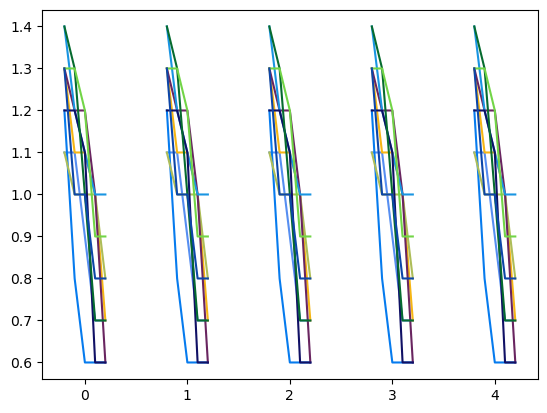

In [41]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

for i in range(10):
    colour = np.random.rand(3,)
    g = gen_attr(df_coeffs_init)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(g)[np.arange(0, 25, 5) + c]
        ax.plot(xs, ys, color=colour)
        offset += 0.1
plt.show()

In [42]:
def clip_coeffs(coeffs):
    # Clip coefficients to sit within allowed range.
    return np.clip(coeffs, a_min=0.0, a_max=10.0,).tolist()

In [43]:
def force_coeffs_increasing(coeffs):
    """
    Make sure each coefficient is no larger than the next.
    """
    def check_success(coeffs_grid):
        # # Check difference along each row:
        # q_ok = (np.sign(np.diff(coeffs_grid, axis=1)) >= 0).all()
        # # Check difference along each column:
        # age_ok = (np.sign(np.diff(coeffs_grid, axis=0)) >= 0).all()
        signs_age, signs_q = check_pattern(coeffs_grid)
        age_ok = (signs_age == 0).all()
        q_ok = (signs_q == 0).all()
        return (q_ok & age_ok)
    
    def check_pattern(coeffs_grid):
        # Start with a 5x5 grid:
        signs_age = np.zeros((5, 5), dtype=int)
        signs_q = np.zeros((5, 5), dtype=int)
        # Fill in all but the first row/column with diffs:
        signs_age[1:, :] = (np.sign(np.diff(coeffs_grid, axis=0)) > 0).astype(int)
        signs_q[:, :-1] = (np.sign(np.diff(coeffs_grid, axis=1)) < 0).astype(int)
        return signs_age, signs_q
    
    def sort_inds_by_farthest(inds):
        if len(inds[0]) < 2:
            # Don't bother if there's nothing to sort.
            return inds
        else:
            pass

        # Gather rows and columns into one array:
        inds_stack = np.vstack(inds)
        # Find the largest row/column:
        max_ind = np.max(inds_stack, axis=0)
        # Find the order that would sort them from largest to smallest:
        inds_sort = np.argsort(max_ind)[::-1]
        # Sort the inds:
        inds = (inds[0][inds_sort], inds[1][inds_sort])
        return inds
        
    coeffs_grid = np.array(coeffs).reshape(5, 5)
    success = check_success(coeffs_grid)

    count = 0
    while success == False:
        signs_age, signs_q = check_pattern(coeffs_grid)
        # Pick out which values don't fit the pattern.
        # Each inds tuple has an array of the row indices, inds[0],
        # and then an array of the column indices, inds[1].
        inds_to_change_age = np.where(signs_age > 0)
        inds_to_change_q = np.where(signs_q > 0)
        inds_to_change_both = np.where((signs_q > 0) & (signs_age > 0))
        # Order the inds, farthest row/column first:
        inds_to_change_age = sort_inds_by_farthest(inds_to_change_age)
        inds_to_change_q = sort_inds_by_farthest(inds_to_change_q)
        inds_to_change_both = sort_inds_by_farthest(inds_to_change_both)

        # Nudge the values, starting from the far edges.
        if len(inds_to_change_both[0]) > 0:
            # Set the breaking value to whichever is smaller of its
            # adjacent coefficients.
            ind_row = inds_to_change_both[0][0]
            ind_col = inds_to_change_both[1][0]
            # Pick out the next values along:
            next_age = coeffs_grid[ind_row - 1, ind_col]
            next_q = coeffs_grid[ind_row, ind_col + 1]
            # Find the smaller one:
            new_val = np.min([next_q, next_age])
            # Update the coefficient:
            coeffs_grid[ind_row, ind_col] = new_val
        elif len(inds_to_change_age[0]) > 0:
            # Set the breaking value to the next age up.
            ind_row = inds_to_change_age[0][0]
            ind_col = inds_to_change_age[1][0]
            # Pick out the next value along:
            new_val = coeffs_grid[ind_row - 1, ind_col]
            # Update the coefficient:
            coeffs_grid[ind_row, ind_col] = new_val
        else:
            # Set the breaking value to the next q up.
            ind_row = inds_to_change_q[0][0]
            ind_col = inds_to_change_q[1][0]
            # Pick out the next value along:
            new_val = coeffs_grid[ind_row, ind_col + 1]
            # Update the coefficient:
            coeffs_grid[ind_row, ind_col] = new_val

        success = check_success(coeffs_grid)
        count += 1
        if count > 100:
            # Give up.
            success = True
    
    return coeffs_grid.flatten().tolist()

Check the force-increasing function:

In [44]:
coeffs = np.arange(25).reshape(5, 5)[::-1].flatten()
coeffs[21] += 12

print(np.array(coeffs).reshape(5, 5))

np.array(force_coeffs_increasing(coeffs)).reshape(5, 5)

[[20 21 22 23 24]
 [15 16 17 18 19]
 [10 11 12 13 14]
 [ 5  6  7  8  9]
 [ 0 13  2  3  4]]


array([[20, 21, 22, 23, 24],
       [15, 16, 17, 18, 19],
       [10, 11, 12, 13, 14],
       [ 5,  6,  7,  8,  9],
       [ 0,  2,  2,  3,  4]])

## Set up algorithm


In [45]:
creator.create("FitnessMax", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

In [46]:
toolbox = base.Toolbox()

# Attribute generator 
#                      define 'attr_bool' to be an attribute ('gene')
#                      which corresponds to integers sampled uniformly
#                      from the range [0,1] (i.e. 0 or 1 with equal
#                      probability)
# toolbox.register("attr_unif", random.uniform, 0, 1)

# Structure initializers
#                         define 'individual' to be an individual
#                         consisting of 100 'attr_bool' elements ('genes')
# toolbox.register("individual", tools.initIterate, creator.Individual, gen_attr, start_ranges_by_coeff)


In [49]:
# # def mutate_coeffs(mutate_means_by_coeff, mutate_stds_by_coeff, individual, indpb=0.05):
# def mutate_coeffs(individual, indpb=0.04):
#     m = 0.0
#     s = 0.05
    
#     mutated = []
#     for i, current_val in enumerate(individual):
#         if random.random() < indpb:
#             # Mutate
#             offset = random.gauss(m, s) - m
#             mutated.append(current_val + offset)
#         else:
#             # Keep current value
#             mutated.append(current_val)
#     return mutated,  # keep comma - DEAP expects to return a tuple

In [83]:
np.random.seed(42)

for i in range(3):
    g = gen_attr(df_coeffs_init)
    print(np.array(g).reshape(5, 5))
    # m = mutate_coeffs(mutate_means_by_coeff, mutate_stds_by_coeff, g, indpb=0.20)
    g = mutate_coeffs(g, indpb=0.05)
    print(np.array(g).reshape(5, 5))
    g = clip_coeffs(g)
    g = round_coeffs(g)
    g = force_coeffs_increasing(g)
    print(np.array(g).reshape(5, 5))
    print('')

[[1.1 1.1 1.1 1.1 1.1]
 [1.1 1.1 1.1 1.1 1.1]
 [1.  1.  1.  1.  1. ]
 [0.6 0.6 0.6 0.6 0.6]
 [0.6 0.6 0.6 0.6 0.6]]
[[1.1        1.06261803 1.1        1.1        1.1       ]
 [1.1        1.17556248 1.1        1.1        1.1       ]
 [1.         1.         1.         1.         1.        ]
 [0.6        0.6        0.6        0.6        0.6       ]
 [0.6        0.70118707 0.6        0.6        0.6       ]]
[[1.062618 1.062618 1.1      1.1      1.1     ]
 [1.062618 1.062618 1.1      1.1      1.1     ]
 [1.       1.       1.       1.       1.      ]
 [0.6      0.6      0.6      0.6      0.6     ]
 [0.6      0.6      0.6      0.6      0.6     ]]

[[1.2 1.2 1.2 1.2 1.2]
 [1.1 1.1 1.1 1.1 1.1]
 [0.8 0.8 0.8 0.8 0.8]
 [0.8 0.8 0.8 0.8 0.8]
 [0.7 0.7 0.7 0.7 0.7]]
[[1.2        1.2        1.2        1.2        1.2       ]
 [1.1        1.0592616  1.1        1.1        1.1       ]
 [0.8        0.8        0.8        0.8        0.8       ]
 [0.79659418 0.8        0.8        0.8        0.8       ]
 [0

In [51]:
#----------
# Operator registration
#----------


toolbox.register("gen_attr", gen_attr, df_coeffs_init)

toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.gen_attr)

# define the population to be a list of individuals
# but don't specify how many here.
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


# register the crossover operator
# toolbox.register("mate", tools.cxUniform, indpb=0.4)
toolbox.register("mate", tools.cxTwoPoint)

In [89]:
# register a mutation operator with a probability to
# flip each attribute/gene of 0.05
# toolbox.register("mutate", tools.mutGaussian, mu=1e-4, sigma=1e-3, indpb=0.05)
toolbox.register("mutate", tools.mutGaussian, mu=0.0, sigma=0.05, indpb=0.04)  # approx 1 in 25 change of mutation
# toolbox.register('mutate', mutate_coeffs, indpb=0.04)  # approx 1 in 25 change of mutation

In [53]:
# operator for selecting individuals for breeding the next
# generation: each individual of the current generation
# is replaced by the 'fittest' (best) of three individuals
# drawn randomly from the current generation.
toolbox.register("select", tools.selTournament, tournsize=3)

#----------

toolbox.register("clip", clip_coeffs)
toolbox.register("round", round_coeffs)
toolbox.register("force_increasing", force_coeffs_increasing)

Example starting population:

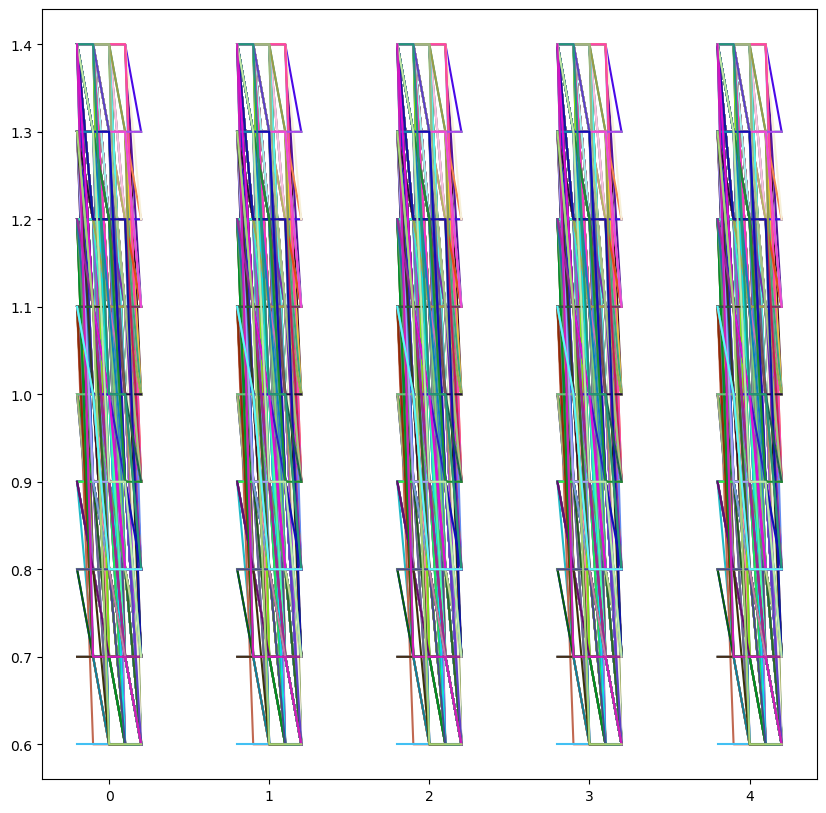

In [54]:
np.random.seed(424242)
pop = toolbox.population(n=500)

fig, ax = plt.subplots(figsize=(10, 10))

for i, individual in enumerate(pop):
    colour = np.random.rand(3,)
    # g = gen_attr(df_coeffs_init)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(individual)[np.arange(0, 25, 5) + c]
        ax.plot(xs, ys, color=colour)
        offset += 0.1
plt.show()

## Run

Run for each IMD band separately.

In [223]:
def main(seed, output_dir='', g=0, cancel_gen=1000):
    random.seed(seed)

    # create an initial population of 300 individuals (where
    # each individual is a list of integers)
    pop = toolbox.population(n=200)

    # CXPB  is the probability with which two individuals
    #       are crossed
    #
    # MUTPB is the probability for mutating an individual
    CXPB = 0.8
    MUTPB = 0.95

    # Keep a copy of the printed text:
    log = ''
    log += "Start of evolution\n"

    # Evaluate the entire population
    fitnesses = list(map(toolbox.evaluate, pop))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    log += f"  Evaluated {len(pop)} individuals\n"

    # Extracting all the fitnesses of 
    fits = [ind.fitness.values[0] for ind in pop]

    # Keep a copy of the best individual in each generation:
    best_inds = []
    
    # Variable keeping track of the number of generations
    # g = 0

    # Begin the evolution
    carry_on_please = True
    while carry_on_please:
        # A new generation
        log += f'-- Generation {g} --\n'
        print(f'-- Generation {g} --', end='\r')
        # print(f'-- Generation {g} --')
        # print(pop)

        # Select the next generation individuals
        offspring = toolbox.select(pop, len(pop))
        # Clone the selected individuals
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover and mutation on the offspring
        for child1, child2 in zip(offspring[::2], offspring[1::2]):

            # cross two individuals with probability CXPB
            if random.random() < CXPB:
                toolbox.mate(child1, child2)

                # fitness values of the children
                # must be recalculated later
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            # mutate an individual with probability MUTPB
            if random.random() < MUTPB:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        
        # Clip values to fit within parameter bounds.
        for ind in invalid_ind:
            ind[:] = toolbox.clip(ind)
        # Round values.
        for ind in invalid_ind:
            ind[:] = toolbox.round(ind)
        # Force coefficients to increase with age band.
        for ind in invalid_ind:
            ind[:] = toolbox.force_increasing(ind)
        
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        log += f"  Evaluated {len(invalid_ind)} individuals\n"

        # The population is entirely replaced by the offspring
        pop[:] = offspring

        # Gather all the fitnesses in one list and print the stats
        fits = [ind.fitness.values[0] for ind in pop]

        length = len(pop)
        mean = sum(fits) / length
        sum2 = sum(x*x for x in fits)
        std = abs(sum2 / length - mean**2)**0.5

        log += f'  Min {min(fits):9.5f}\n'
        log += f'  Max {max(fits):9.5f}\n'
        log += f'  Avg {mean:9.5f}\n'
        log += f'  Std {std:9.5f}\n'
            
        best_ind = tools.selBest(pop, 1)[0]
        best_ind_str = ', '.join([f'{b:9.7f}' for b in best_ind])
        b = best_ind.fitness.values[0]
        log += f'Best individual is ({best_ind_str}), {b:.5f}\n'

        best_inds.append(best_ind)

        # Check continue condition
        c = np.array(pop).std(axis=0) / np.array(pop).mean(axis=0)
        if (c < 0.05).all():
            carry_on_please = False
            log += "-- End of (successful) evolution --\n"
        elif g > (cancel_gen - 1):
            carry_on_please = False
            log += "-- End of evolution --\n"
            log += "(cancelled after 1000 generations)\n"
        else:
            g = g + 1

        if (g % 10 == 0) | (carry_on_please == False):
            # Save results.
            arr = np.array(pop)
            fits = [ind.fitness.values[0] for ind in pop]
            arr = np.hstack((arr, np.array(fits).reshape(len(fits), 1)))
            np.savetxt(os.path.join('outputs', output_dir, f'gen{g:04d}.csv'), arr, fmt='%.6f', delimiter=',', header=','.join(coeff_names + ['fitness']))


    return pop, best_inds, log, g

Evaluate over all q bands at once.

In [117]:
# the goal ('fitness') function to be maximized
def eval_admissions(coeffs_ssnap, admissions_lists, x_lists, individual):

    predictions_lists = []
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        coeffs = individual[(i*5):(i*5)+5] * np.array(coeffs_ssnap)
        yhat = predict_admissions(x_lists_here, coeffs)
        predictions_lists.append(yhat)

    # Combine lists:
    observed_all = sum(admissions_lists, [])
    predicted_all = sum(predictions_lists, [])
    # Use only one of the following options for checking the fit:
    sum_sqres = find_square_residuals(predicted_all, observed_all)
    # sum_sqres = find_mean_abs_diff(yhat, admissions)
    return sum_sqres,

In [118]:
admissions_lists = []
x_lists = []

for qmin in qmin_list:
    df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    # MSOA data in the same order as those coefficients:
    x_lists_here = [df_stats_here[a] for a in age_numbers]
    admissions_here = df_stats_here['admissions'].to_numpy().tolist()
    # Store:
    admissions_lists.append(admissions_here)
    x_lists.append(x_lists_here)

# For this deprivation quantile, need to pass these admissions
# into the evaluation function:
# register the goal / fitness function
toolbox.register("evaluate", eval_admissions, coeffs_ssnap, admissions_lists, x_lists)

In [119]:
eval_admissions(coeffs_ssnap, admissions_lists, x_lists, gen_attr(df_coeffs_init))

(408.27769136662977,)

In [222]:
gens

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [224]:
for seed in range(2):
    start_gen = 1
    output_dir = f'randomseed{seed:02d}'
    pop_results, best_inds, log, end_gen = main(seed=seed, output_dir=output_dir, g=start_gen, cancel_gen=15)
    # Store a copy of the best results:
    with open(os.path.join('outputs', output_dir, 'log.txt'), 'w') as text_file:
        text_file.write(log)
    
    arr = np.array(best_inds)
    fits = [ind.fitness.values[0] for ind in best_inds]
    gens = np.arange(start_gen, end_gen+1, 1)
    arr = np.hstack((gens.reshape(len(gens), 1), arr, np.array(fits).reshape(len(fits), 1)))
    np.savetxt(os.path.join('outputs', output_dir, f'best_inds_by_gen.csv'), arr, fmt='%.6f', delimiter=',', header=','.join(['gen'] + coeff_names + ['fitness']))

In [210]:
[ind.fitness.values[0] for ind in best_inds]

[239.55569435828403,
 239.42645057503506,
 239.1909812997804,
 238.8587454658557,
 238.34509567878644,
 238.492885571369,
 238.3474123740283,
 238.25651121181892,
 238.25651121181892,
 238.2033682905862,
 238.09839702015566,
 238.0464243477435,
 238.05717427520497,
 237.97942158070535,
 237.8566525603909,
 237.86380330076062,
 237.7674652674434,
 237.74648571060877,
 237.59565602169573,
 237.54108531248045,
 237.5817999950951,
 237.5930772250801,
 237.58273596774288,
 237.54935807791404,
 237.5356054551499,
 237.4996214618141,
 237.4996214618141,
 237.4996214618141,
 237.5134260953005,
 237.50230705119426,
 237.48242013556052,
 237.48242013556052,
 237.48242013556052,
 237.47590452432186,
 237.47590452432186,
 237.47590452432186,
 237.46241310201592,
 237.4535265832147,
 237.45125097988569,
 237.45228426634554,
 237.44546915302277,
 237.44040334167292,
 237.44040334167292,
 237.43398642462105,
 237.43083422013308,
 237.42550092944498,
 237.42550092944498,
 237.41671989029385,
 237.4119

In [163]:
print(log)

Start of evolution
  Evaluated 200 individuals
-- Generation 1 --
  Evaluated 200 individuals
  Min 239.55569
  Max 364.79747
  Avg 279.67504
  Std  24.99750
Best individual is (1.2636350, 1.3000000, 1.3000000, 1.4000000, 1.4000000, 1.1000000, 1.1000000, 1.1000000, 1.1000000, 1.1000000, 0.9000000, 0.9000000, 1.1000000, 1.1000000, 1.1000000, 0.9000000, 0.9000000, 1.0000000, 1.0000000, 1.0000000, 0.9000000, 0.9000000, 0.9000000, 0.9000000, 0.9000000), 239.55569
-- Generation 2 --
  Evaluated 196 individuals
  Min 239.42645
  Max 300.90843
  Avg 259.84557
  Std  15.10981
Best individual is (1.2636350, 1.3000000, 1.3000000, 1.3381640, 1.4000000, 1.1000000, 1.1000000, 1.1000000, 1.1000000, 1.1000000, 0.9000000, 0.9000000, 1.1000000, 1.1000000, 1.1000000, 0.9000000, 0.9000000, 1.0000000, 1.0000000, 1.0000000, 0.9000000, 0.9000000, 0.9000000, 0.9000000, 0.9000000), 239.42645
-- Generation 3 --
  Evaluated 197 individuals
  Min 239.19098
  Max 277.78827
  Avg 248.27687
  Std   6.75929
Best ind

In [164]:
for individual in pop_results[:10]:
    print(individual)

[1.3, 1.3, 1.3, 1.3, 1.324999, 1.1, 1.1, 1.1, 1.1, 1.245856, 0.892399, 0.892399, 0.892399, 0.972576, 1.202214, 0.767632, 0.767632, 0.767632, 0.767632, 1.158843, 0.637626, 0.637626, 0.637626, 0.637626, 1.158843]
[1.269112, 1.269112, 1.269112, 1.269112, 1.269112, 1.1, 1.1, 1.1, 1.1, 1.202214, 0.892399, 0.892399, 0.892399, 0.892399, 1.202214, 0.767632, 0.767632, 0.767632, 0.767632, 1.202214, 0.637626, 0.637626, 0.637626, 0.637626, 1.202214]
[1.3, 1.3, 1.3, 1.3, 1.324999, 1.1, 1.1, 1.1, 1.1, 1.202214, 0.892399, 0.892399, 0.892399, 0.892399, 1.202214, 0.767632, 0.767632, 0.767632, 0.767632, 1.202214, 0.620516, 0.620516, 0.620516, 0.620516, 1.202214]
[1.3, 1.3, 1.3, 1.3, 1.324999, 1.1, 1.1, 1.1, 1.1, 1.202214, 0.854558, 0.892399, 0.892399, 0.892399, 1.202214, 0.767632, 0.767632, 0.767632, 0.772439, 1.202214, 0.620516, 0.620516, 0.637626, 0.637626, 1.202214]
[1.281374, 1.281374, 1.281374, 1.281374, 1.281374, 1.1, 1.1, 1.1, 1.1, 1.202214, 0.892399, 0.892399, 0.892399, 0.892399, 1.202214, 0.767

In [165]:
best_unique, best_unique_inds = np.unique(np.array(best_inds), axis=0, return_index=True)

inds_to_sort = np.argsort(best_unique_inds)
best_unique_inds = best_unique_inds[inds_to_sort]
best_unique = np.array(best_inds)[best_unique_inds]

In [166]:
best_unique_inds

array([  0,   1,   2,   3,   4,   5,   6,   7,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  28,
        29,  30,  33,  36,  37,  38,  39,  40,  41,  43,  44,  45,  47,
        48,  49,  50,  51,  52,  53,  57,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  72,  73,  74,  75,  76,  77,  78,  79,
        80,  81,  82,  83,  84,  85,  86,  87,  88,  91,  92,  93,  94,
        95,  96,  97, 100, 101, 102, 105, 106, 108, 109, 111, 112, 114,
       115, 117, 118, 119, 120, 122, 123, 125, 126, 127, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 144, 145,
       147, 149, 150, 151, 152, 154, 155, 157, 158, 159, 161, 167, 168,
       169, 171, 172, 173, 174, 177, 178, 180, 181, 183, 184, 188, 189,
       191, 193, 194, 195, 196, 197, 198, 202, 204, 206, 207, 208, 209,
       210, 212, 214, 216, 217, 218, 220, 223, 224, 225, 227, 228, 238,
       241, 242, 246, 249, 250, 251, 254, 257, 259, 265, 266, 26

In [167]:
best_unique

array([[1.263635, 1.3     , 1.3     , ..., 0.9     , 0.9     , 0.9     ],
       [1.263635, 1.3     , 1.3     , ..., 0.9     , 0.9     , 0.9     ],
       [1.263635, 1.3     , 1.3     , ..., 0.9     , 0.9     , 0.9     ],
       ...,
       [1.3     , 1.3     , 1.3     , ..., 0.637807, 0.637807, 1.202214],
       [1.3     , 1.3     , 1.3     , ..., 0.637807, 0.637807, 1.202214],
       [1.3     , 1.3     , 1.3     , ..., 0.637626, 0.637626, 1.202214]])

In [168]:
coeff_names

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

Plot best coeffs across generations:

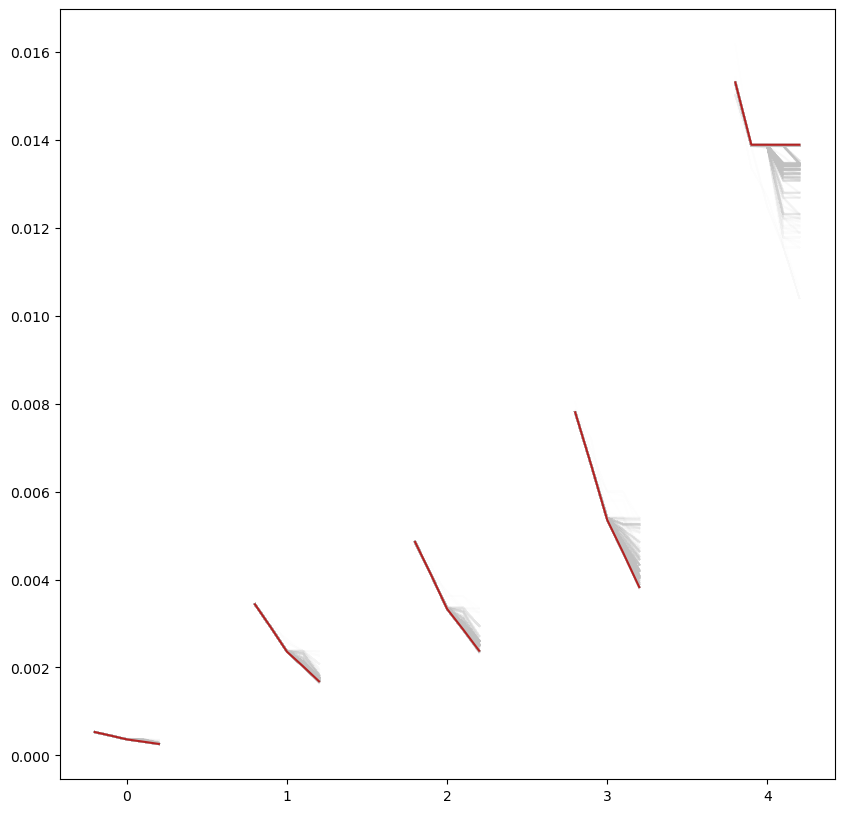

In [169]:
# 42
# colours = plt.get_cmap('viridis')(np.linspace(0.0, 1.0, len(best_inds)))

fig, ax = plt.subplots(figsize=(10, 10))


# offset = -0.2
# for c in range(5):
#     xs = np.arange(-0.2, 0.3, 0.1) + c
#     ys = np.array(best_coeffs)[np.arange(0, 25, 5) + c]
#     ax.plot(xs, ys, color='k', zorder=0, linewidth=5, label=('Input best fit' if c==0 else None))
#     offset += 0.1
    
for i, best in enumerate(best_unique):
    ind = best_unique_inds[i]

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(best)[np.arange(0, 25, 5) + c] * np.array([coeffs_ssnap[c]] * 5)
        alpha = 1.0 if (ind == best_unique_inds[-1]) else (0.6 * i / (len(best_inds)-1))
        colour = 'FireBrick' if (ind == best_unique_inds[-1]) else 'silver'
        ax.plot(
            xs, ys,
            color=colour,  # colours[ind],
            zorder=1, label=(f'{ind}' if c==0 else None), alpha=alpha)
        offset += 0.1

# ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')

plt.show()

Plot final generation population:

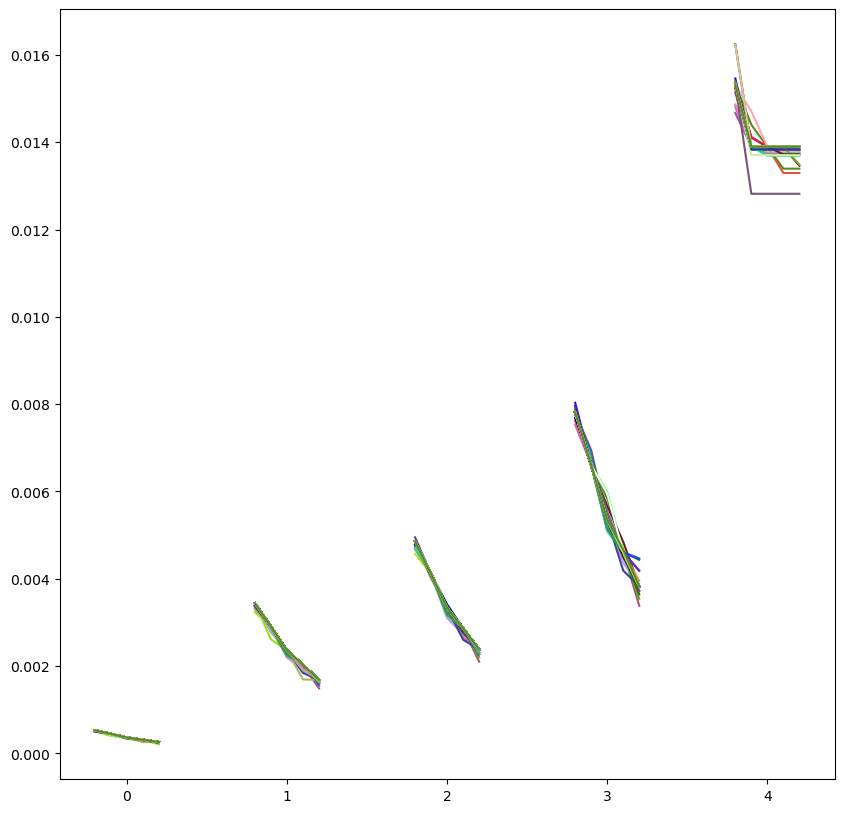

In [170]:
# 42

# np.random.seed(424242)
# pop = toolbox.population(n=500)

fig, ax = plt.subplots(figsize=(10, 10))

# offset = -0.2
# for c in range(5):
#     xs = np.arange(-0.2, 0.3, 0.1) + c
#     ys = np.array(best_coeffs)[np.arange(0, 25, 5) + c]
#     ax.plot(xs, ys, color='k', zorder=0, linewidth=5, label=('Input best fit' if c==0 else None))
#     offset += 0.1
    
for i, individual in enumerate(pop_results):
    colour = np.random.rand(3,)
    # g = gen_attr(df_coeffs_init)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(individual)[np.arange(0, 25, 5) + c] * np.array([coeffs_ssnap[c]] * 5)
        ax.plot(xs, ys, color=colour, zorder=1, label=(f'{ind}' if c==0 else None))
        offset += 0.1


plt.show()

In [171]:
best_inds_42 = best_inds[-1]

np.array(best_inds_42).reshape(5, 5)

array([[1.3     , 1.3     , 1.3     , 1.3     , 1.324999],
       [1.1     , 1.1     , 1.1     , 1.1     , 1.202214],
       [0.892399, 0.892399, 0.892399, 0.892399, 1.202214],
       [0.767632, 0.767632, 0.767632, 0.767632, 1.202214],
       [0.637626, 0.637626, 0.637626, 0.637626, 1.202214]])

In [172]:
for coeffs in [best_inds_42]:
    predictions_lists = []
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        c = np.array(coeffs[(i*5):(i*5)+5]) * np.array(coeffs_ssnap)
        yhat = predict_admissions(x_lists_here, c)
        predictions_lists.append(yhat)

    # Combine lists:
    observed_all = sum(admissions_lists, [])
    predicted_all = sum(predictions_lists, [])
    # Calculate r-squared:
    r2 = calculate_rsquared(observed_all, predicted_all)
    print(r2)

0.5947848048582136


In [173]:
for coeffs in [best_inds_42]:
    print(np.array(coeffs).reshape(5, 5) * coeffs_ssnap)

[[0.0005304  0.0034372  0.0048555  0.0078065  0.01531434]
 [0.0004488  0.0029084  0.0041085  0.0066055  0.01389519]
 [0.0003641  0.0023595  0.00333311 0.00535886 0.01389519]
 [0.00031319 0.00202962 0.00286711 0.00460963 0.01389519]
 [0.00026015 0.00168588 0.00238153 0.00382894 0.01389519]]


Save population to file:

array([[  1.3       ,   1.3       ,   1.3       , ...,   0.637626  ,
          1.158843  , 237.69251241],
       [  1.269112  ,   1.269112  ,   1.269112  , ...,   0.637626  ,
          1.202214  , 237.55192769],
       [  1.3       ,   1.3       ,   1.3       , ...,   0.620516  ,
          1.202214  , 237.12086105],
       ...,
       [  1.3       ,   1.3       ,   1.3       , ...,   0.657601  ,
          1.202214  , 237.08234144],
       [  1.3       ,   1.3       ,   1.3       , ...,   0.637626  ,
          1.202214  , 237.07442995],
       [  1.3       ,   1.3       ,   1.3       , ...,   0.637626  ,
          1.202214  , 237.0777814 ]])

In [200]:
arr

array([[1.3     , 1.3     , 1.3     , ..., 0.637626, 0.637626, 1.158843],
       [1.269112, 1.269112, 1.269112, ..., 0.637626, 0.637626, 1.202214],
       [1.3     , 1.3     , 1.3     , ..., 0.620516, 0.620516, 1.202214],
       ...,
       [1.3     , 1.3     , 1.3     , ..., 0.637626, 0.657601, 1.202214],
       [1.3     , 1.3     , 1.3     , ..., 0.637626, 0.637626, 1.202214],
       [1.3     , 1.3     , 1.3     , ..., 0.637626, 0.637626, 1.202214]])

In [198]:


fits

[237.69251241316528,
 237.55192769477543,
 237.12086104813082,
 237.13924897361028,
 237.31258085624233,
 237.074429950847,
 237.09037636272265,
 237.2430519498244,
 237.45257847022378,
 237.074429950847,
 237.08069608098322,
 237.95623279147642,
 237.074429950847,
 237.07653737001544,
 237.074429950847,
 237.07812194083635,
 237.36343444442804,
 237.074429950847,
 237.074429950847,
 237.65825609190236,
 237.074429950847,
 237.07973371873922,
 237.074429950847,
 237.07478629644015,
 237.074429950847,
 237.074429950847,
 237.4563113113438,
 237.074429950847,
 237.074429950847,
 237.07669163729116,
 237.09639079187724,
 237.074429950847,
 237.65308020925073,
 237.11354528392624,
 237.4357920095251,
 237.1713351501288,
 237.24303363649827,
 237.074429950847,
 237.16710771467072,
 237.074429950847,
 237.074429950847,
 237.12777413512381,
 237.074429950847,
 237.40674240272082,
 237.0827994517075,
 237.3532483283177,
 237.5720900775786,
 237.074429950847,
 237.074429950847,
 237.08245777398

In [178]:
coeff_names

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

In [181]:
arr.shape

(200, 25)

In [183]:
arr

array([[1.3     , 1.3     , 1.3     , ..., 0.637626, 0.637626, 1.158843],
       [1.269112, 1.269112, 1.269112, ..., 0.637626, 0.637626, 1.202214],
       [1.3     , 1.3     , 1.3     , ..., 0.620516, 0.620516, 1.202214],
       ...,
       [1.3     , 1.3     , 1.3     , ..., 0.637626, 0.657601, 1.202214],
       [1.3     , 1.3     , 1.3     , ..., 0.637626, 0.637626, 1.202214],
       [1.3     , 1.3     , 1.3     , ..., 0.637626, 0.637626, 1.202214]])

[0.000408,
 0.002644,
 0.003735,
 0.006005,
 0.011558,
 0.000408,
 0.002644,
 0.003735,
 0.006005,
 0.011558,
 0.000408,
 0.002644,
 0.003735,
 0.006005,
 0.011558,
 0.000408,
 0.002644,
 0.003735,
 0.006005,
 0.011558,
 0.000408,
 0.002644,
 0.003735,
 0.006005,
 0.011558]

In [192]:
meanses = (arr * (np.array(sum([coeffs_ssnap]*5, [])))).mean(axis=0)
stdses = (arr * (np.array(sum([coeffs_ssnap]*5, [])))).std(axis=0)

stdses/meanses

array([0.00996516, 0.00737305, 0.0062168 , 0.00465614, 0.00752596,
       0.01101001, 0.00851951, 0.00254626, 0.00437682, 0.00764861,
       0.01307713, 0.01121775, 0.01022643, 0.01558657, 0.00579438,
       0.01789358, 0.01591497, 0.00970519, 0.00857235, 0.00702803,
       0.02246244, 0.01333534, 0.01162094, 0.02161346, 0.007617  ])

In [193]:
meanses = (arr).mean(axis=0)
stdses = (arr).std(axis=0)

stdses/meanses

array([0.00996516, 0.00737305, 0.0062168 , 0.00465614, 0.00752596,
       0.01101001, 0.00851951, 0.00254626, 0.00437682, 0.00764861,
       0.01307713, 0.01121775, 0.01022643, 0.01558657, 0.00579438,
       0.01789358, 0.01591497, 0.00970519, 0.00857235, 0.00702803,
       0.02246244, 0.01333534, 0.01162094, 0.02161346, 0.007617  ])

In [175]:
print(stop, here, please)

NameError: name 'stop' is not defined

In [ ]:
list_coeff_init_r2 = []

for coeff_combo in df_coeffs_init['coeff_combo']:
    coeffs = df_coeffs_init.filter(df_coeffs_init['coeff_combo'] == coeff_combo)[coeff_names].to_numpy()[0].tolist()

    predictions_lists = []
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        c = coeffs[(i*5):(i*5)+5]
        yhat = predict_admissions(x_lists_here, c)
        predictions_lists.append(yhat)

    # Combine lists:
    observed_all = sum(admissions_lists, [])
    predicted_all = sum(predictions_lists, [])
    # Calculate r-squared:
    r2 = calculate_rsquared(observed_all, predicted_all)
    list_coeff_init_r2.append(r2)

In [ ]:
df_coeffs_init = pl.concat((df_coeffs_init, pl.Series('r2', list_coeff_init_r2).to_frame()), how='horizontal')

In [ ]:
df_coeffs_init.sort('r2', descending=True)

In [ ]:
best_coeffs_init = df_coeffs_init.sort('r2', descending=True)['coeff_combo'].to_numpy()

In [ ]:
for coeff_combo in best_coeffs_init[:10]:
    coeffs = df_coeffs_init.filter(df_coeffs_init['coeff_combo'] == coeff_combo)[coeff_names]
    print(coeffs.to_numpy().reshape(5, 5))
    print('')